In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import seaborn as sns
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [9]:
# df_raw = pd.read_csv("data/nse_data.csv")
df_raw = pd.read_parquet("data/processed/crypto_pct_chg.parquet")
df_raw.head()

asset,BTC,ETH,SOL,XRP
close_time,,,,
2017-08-17 04:14:59.999000+00:00,NaN,NaN,NaN,NaN
2017-08-17 04:29:59.999000+00:00,-0.000007,0.004654,NaN,NaN
2017-08-17 04:44:59.999000+00:00,0.011345,0.000701,NaN,NaN
2017-08-17 04:59:59.999000+00:00,-0.000288,0.006687,NaN,NaN
2017-08-17 05:14:59.999000+00:00,-0.001050,0.001325,NaN,NaN


In [10]:
df = df_raw.copy()

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df = df.set_index("date")
elif not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, utc=True)

df = df.sort_index()

if df.index.tz is not None:
    split_date = pd.Timestamp("2025-07-01", tz=df.index.tz)
else:
    split_date = pd.Timestamp("2025-07-01")

train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

train_returns = train.dropna(how="all")
test_returns = test.dropna(how="all")

print(f"Train rows: {len(train_returns)}")
print(f"Test rows: {len(test_returns)}")

print(train_returns.tail())
print(test_returns.head())

Train rows: 275444
Test rows: 35041
asset                                  BTC       ETH       SOL       XRP
close_time                                                              
2025-06-30 22:59:59.999000+00:00 -0.001495 -0.001825 -0.001931 -0.005692
2025-06-30 23:14:59.999000+00:00  0.000982  0.001208  0.003538 -0.004835
2025-06-30 23:29:59.999000+00:00 -0.000674 -0.001148 -0.001671 -0.003028
2025-06-30 23:44:59.999000+00:00 -0.000054 -0.000165 -0.001674  0.000713
2025-06-30 23:59:59.999000+00:00  0.000061 -0.001893 -0.002516 -0.003304
asset                                  BTC       ETH       SOL       XRP
close_time                                                              
2025-07-01 00:14:59.999000+00:00  0.001758  0.003073  0.000323  0.003972
2025-07-01 00:29:59.999000+00:00 -0.001542 -0.003476 -0.005634 -0.002631
2025-07-01 00:44:59.999000+00:00  0.001062  0.001737  0.002270  0.000223
2025-07-01 00:59:59.999000+00:00  0.000870  0.001831  0.002718 -0.000625
2025-07-01 01:1

In [11]:
train_returns.to_parquet("data/processed/train_returns.parquet")
test_returns.to_parquet("data/processed/test_returns.parquet")
print("Train and test returns saved to parquet files.")

Train and test returns saved to parquet files.


In [12]:
# # Use the train set created earlier
# train_df = train_returns.copy() if "train_returns" in globals() else train.copy()

# # Select numeric asset columns
# asset_cols = [
#     c for c in train_df.columns
#     if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
# ]

# if len(asset_cols) == 0:
#     raise ValueError("No numeric asset columns found.")

# rows = []
# var_frames = []

# for asset in asset_cols:
#     s = train_df[asset].dropna()*100

#     if len(s) < 50:
#         continue

#     # Fit GARCH(1,1) on the train data
#     model = arch_model(
#         s,
#         vol="Garch",
#         p=1,
#         o=0,
#         q=1,
#         dist="t"
#     ).fit(disp="off", show_warning=False)

#     # Generated variable: conditional variance
#     cond_var = pd.Series(model.conditional_volatility**2, index=s.index, name=asset)
#     var_frames.append(cond_var.to_frame())

#     # Store model summary in a row
#     row = {
#         "asset": asset,
#         "model": "GARCH(1,1)",
#         "omega": model.params["omega"] if "omega" in model.params.index else np.nan,
#         "alpha1": model.params["alpha[1]"] if "alpha[1]" in model.params.index else np.nan,
#         "beta1": model.params["beta[1]"] if "beta[1]" in model.params.index else np.nan,
#         "aic": model.aic,
#         "bic": model.bic,
#         "n_obs": len(s),
#     }
#     rows.append(row)

# model_df = pd.DataFrame(rows)
# garch_var_df = pd.concat(var_frames, axis=1)

# def make_excel_safe(df):
#     df = df.copy()

#     # Remove timezone from index if needed
#     if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
#         df.index = df.index.tz_convert(None)

#     # Remove timezone from datetime columns if needed
#     for col in df.columns:
#         if pd.api.types.is_datetime64tz_dtype(df[col]):
#             df[col] = df[col].dt.tz_convert(None)

#     return df

# model_df = make_excel_safe(model_df)
# garch_var_df = make_excel_safe(garch_var_df)

# os.makedirs("data/processed", exist_ok=True)
# out_file = "data/processed/garch_models.xlsx"

# with pd.ExcelWriter(out_file) as writer:
#     model_df.to_excel(writer, sheet_name="garch_model_results", index=False)
#     garch_var_df.to_excel(writer, sheet_name="garch_fitted_variance")

# print(f"Saved GARCH results to: {out_file}")

# # Save to Excel
# os.makedirs("data/processed", exist_ok=True)
# out_file = "data/processed/garch_models.xlsx"

# with pd.ExcelWriter(out_file) as writer:
#     model_df.to_excel(writer, sheet_name="garch_model_results", index=False)
#     garch_var_df.to_excel(writer, sheet_name="garch_fitted_variance")

# print(f"Saved GARCH results to: {out_file}")
# print("\nModel summary dataframe:")
# print(model_df)

# print("\nGenerated model variable dataframe (conditional variance):")
# print(garch_var_df.head())

In [13]:
# Use the train set created earlier
train_df = train_returns.copy() if "train_returns" in globals() else train.copy()

# Select numeric asset columns
asset_cols = [
    c for c in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
]

if len(asset_cols) == 0:
    raise ValueError("No numeric asset columns found.")

def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

model_specs = [
    ("GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 0, "q": 1}),
    ("GJR-GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 1, "q": 1}),
    ("EGARCH(1,1)", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
]

model_summaries = []
model_var_dfs = []

for model_name, spec in model_specs:
    rows = []
    var_frames = []

    for asset in asset_cols:
        s = train_df[asset].dropna()*100

        if len(s) < 50:
            continue

        model = arch_model(
            s,
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist="t"
        ).fit(disp="off", show_warning=False)

        cond_var = pd.Series(model.conditional_volatility**2, index=s.index, name=asset)
        var_frames.append(cond_var.to_frame())

        row = {
            "asset": asset,
            "model": model_name,
            "aic": model.aic,
            "bic": model.bic,
            "n_obs": len(s),
        }

        for param_name, value in model.params.items():
            row[f"param_{param_name}"] = value

        rows.append(row)

    if len(rows) > 0:
        model_df = pd.DataFrame(rows)
        var_df = pd.concat(var_frames, axis=1)

        model_df = make_excel_safe(model_df)
        var_df = make_excel_safe(var_df)

        model_summaries.append(model_df)
        model_var_dfs.append((model_name, var_df))

summary_df = pd.concat(model_summaries, ignore_index=True) if model_summaries else pd.DataFrame()
combined_var_df = pd.concat(
    [var_df.add_prefix(f"{model_name}::") for model_name, var_df in model_var_dfs],
    axis=1
) if model_var_dfs else pd.DataFrame()

summary_df = make_excel_safe(summary_df)
combined_var_df = make_excel_safe(combined_var_df)

os.makedirs("data/models", exist_ok=True)
out_file = "data/models/arch_models_all.xlsx"

with pd.ExcelWriter(out_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="model_summary", index=False)
    combined_var_df.to_excel(writer, sheet_name="all_model_variances")

print(f"Saved all model results to: {out_file}")
print("\nModel summary dataframe:")
print(summary_df.head())

print("\nCombined variance dataframe:")
print(combined_var_df.head())

C:\Users\Shivam\AppData\Local\Temp\ipykernel_54892\2024828681.py:71: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  var_df = pd.concat(var_frames, axis=1)
C:\Users\Shivam\AppData\Local\Temp\ipykernel_54892\2024828681.py:20: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
C:\Users\Shivam\AppData\Local\Temp\ipykernel_54892\2024828681.py:20: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
C:\Users\Shivam\AppData\Local\Temp\ipykernel_54892\202482868

Saved all model results to: data/models/arch_models_all.xlsx

Model summary dataframe:
  asset           model           aic           bic   n_obs       param_mu  \
0   BTC      GARCH(1,1)  3.398636e+04  3.403899e+04  275418       0.001814   
1   ETH      GARCH(1,1)  1.017411e+08  1.017411e+08  275418 -368631.801189   
2   SOL      GARCH(1,1)  2.527946e+05  2.528448e+05  171241       0.000266   
3   XRP      GARCH(1,1)  1.931147e+05  1.931668e+05  250618       0.001132   
4   BTC  GJR-GARCH(1,1)  6.576423e+06  6.576486e+06  275418    1020.718574   

   param_omega  param_alpha[1]  param_beta[1]   param_nu  param_gamma[1]  
0     0.003422        0.200091       0.780023   4.160230             NaN  
1     0.282758        0.530214       0.276641  32.641435             NaN  
2     0.010067        0.103585       0.876494   4.544985             NaN  
3     0.006766        0.199895       0.780110   4.231500             NaN  
4     1.558038        0.000011       0.226865   2.450473        1.539

In [14]:
def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

df_squared_returns = (train_returns**2).copy()
df_squared_returns = make_excel_safe(df_squared_returns)
df_squared_returns.to_excel("data/processed/squared_returns.xlsx", index=True)
df_squared_returns.head()

# metrics_df = make_excel_safe(metrics_df)
# metrics_df.to_excel("data/processed/variance_metrics_all_assets.xlsx", index=False) 

C:\Users\Shivam\AppData\Local\Temp\ipykernel_54892\3795789751.py:8: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):


asset,BTC,ETH,SOL,XRP
close_time,,,,
2017-08-17 04:29:59.999,4.955924e-11,2.165585e-05,NaN,NaN
2017-08-17 04:44:59.999,1.287015e-04,4.916539e-07,NaN,NaN
2017-08-17 04:59:59.999,8.279416e-08,4.470982e-05,NaN,NaN
2017-08-17 05:14:59.999,1.101575e-06,1.756519e-06,NaN,NaN
2017-08-17 05:29:59.999,1.323909e-05,4.382580e-07,NaN,NaN


<Axes: xlabel='close_time'>

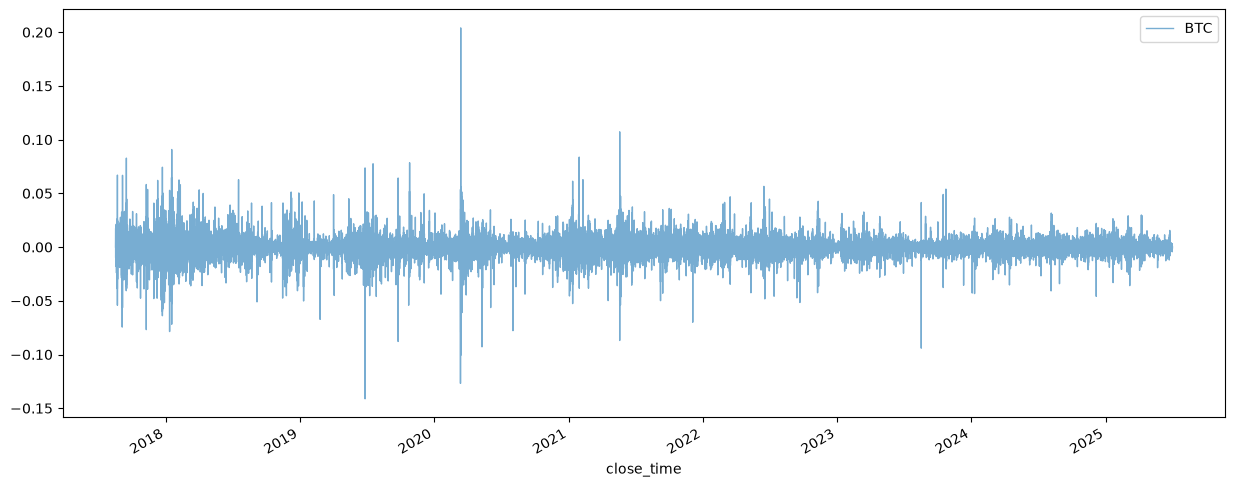

In [15]:
train_returns.plot(y = 'BTC', kind='line', figsize=(15, 6), linewidth=1.0, alpha=0.6)

<Axes: xlabel='close_time'>

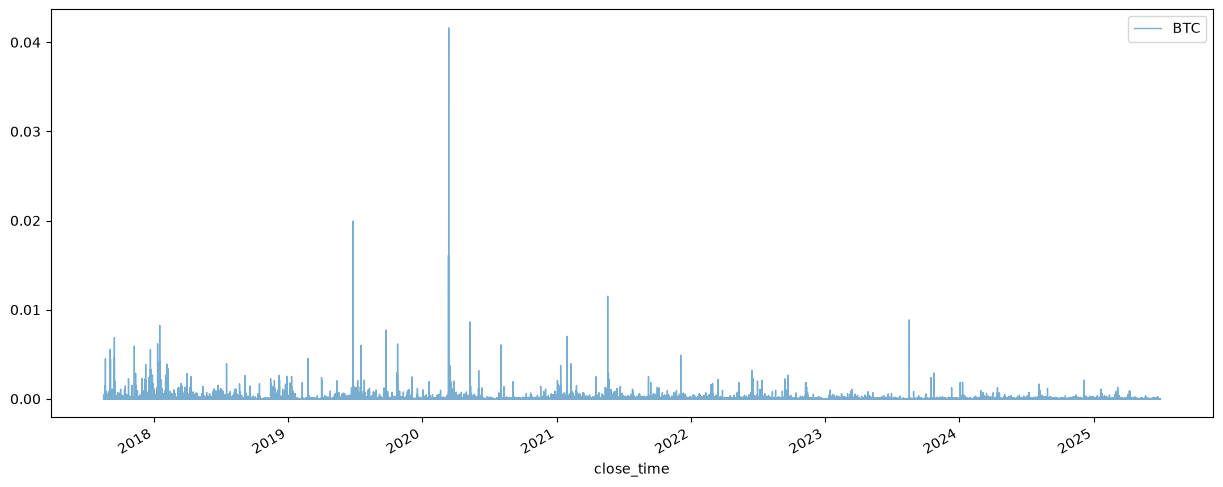

In [16]:
df_squared_returns.plot(y = 'BTC', kind='line', figsize=(15, 6), linewidth=1.0, alpha=0.6)

In [17]:
returns_file = "data/processed/squared_returns.xlsx"
variance_file = "data/models/arch_models_all.xlsx"

returns_df = pd.read_excel(
    returns_file,
    sheet_name="Sheet1"
)

variance_df = pd.read_excel(
    variance_file,
    sheet_name="all_model_variances"
)

# Convert timestamps to datetime
returns_df["close_time"] = pd.to_datetime(
    returns_df["close_time"],
    errors="coerce"
)

variance_df["close_time"] = pd.to_datetime(
    variance_df["close_time"],
    errors="coerce"
)

combined_df = returns_df.merge(
    variance_df,
    on="close_time",
    how="inner"
)

assets = ["BTC", "ETH", "SOL", "XRP"]

models = [
    "GARCH(1,1)",
    "GJR-GARCH(1,1)",
    "EGARCH(1,1)"
]

results = []

for asset in assets:

    squared_return = combined_df[asset] ** 2

    for model in models:

        variance_column = f"{model}::{asset}"

        # Keep only observations where both values are available
        evaluation_df = pd.DataFrame({
            "squared_return": squared_return,
            "conditional_variance": combined_df[variance_column]
        }).replace([np.inf, -np.inf], np.nan).dropna()

        if evaluation_df.empty:
            print(
                f"No valid observations available for "
                f"{asset} using {model}"
            )
            continue

        actual = evaluation_df["squared_return"]
        predicted = evaluation_df["conditional_variance"]

        mae = mean_absolute_error(actual, predicted)

        rmse = np.sqrt(
            mean_squared_error(actual, predicted)
        )

        results.append({
            "Asset": asset,
            "Model": model,
            "Observations": len(evaluation_df),
            "MAE": mae,
            "RMSE": rmse
        })

# Convert results into a DataFrame
error_metrics_df = pd.DataFrame(results)

print(error_metrics_df)

# Display results sorted by asset and RMSE
# ranked_results_df = error_metrics_df.sort_values(
#     by=["Asset", "RMSE"],
#     ascending=[True, True]
# ).reset_index(drop=True)

# print("\nModels ranked by RMSE:")
# print(ranked_results_df)

   Asset           Model  Observations            MAE           RMSE
0    BTC      GARCH(1,1)        275418       0.171196       0.708207
1    BTC  GJR-GARCH(1,1)        275418  154466.050888  320553.372285
2    BTC     EGARCH(1,1)        275418   10014.093912  164407.481937
3    ETH      GARCH(1,1)        275418  255691.879387  760039.982343
4    ETH  GJR-GARCH(1,1)        275418       0.256721       0.812425
5    ETH     EGARCH(1,1)        275418       0.264469       0.863889
6    SOL      GARCH(1,1)        171241       0.505677       1.169955
7    SOL  GJR-GARCH(1,1)        171241       0.505244       1.262379
8    SOL     EGARCH(1,1)        171241       0.623437      19.515534
9    XRP      GARCH(1,1)        250618       0.337181       1.725019
10   XRP  GJR-GARCH(1,1)        250618       0.338763       1.720561
11   XRP     EGARCH(1,1)        250618       2.835112     445.314217


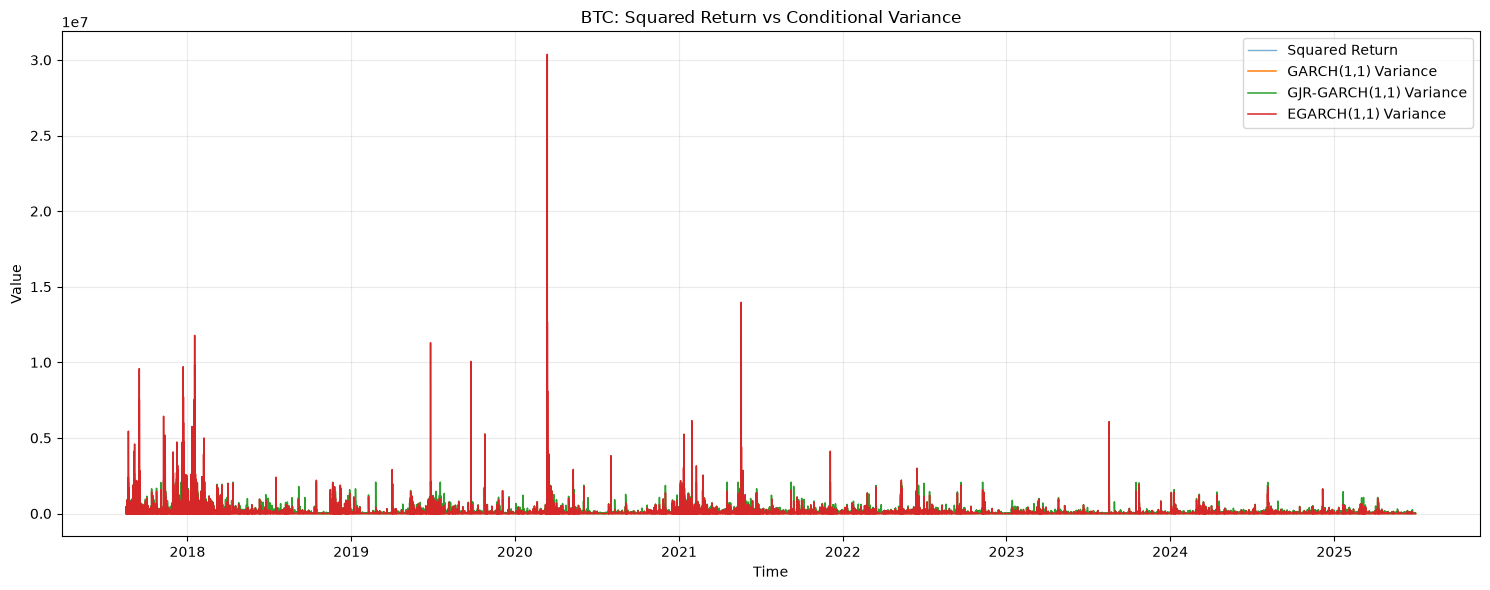

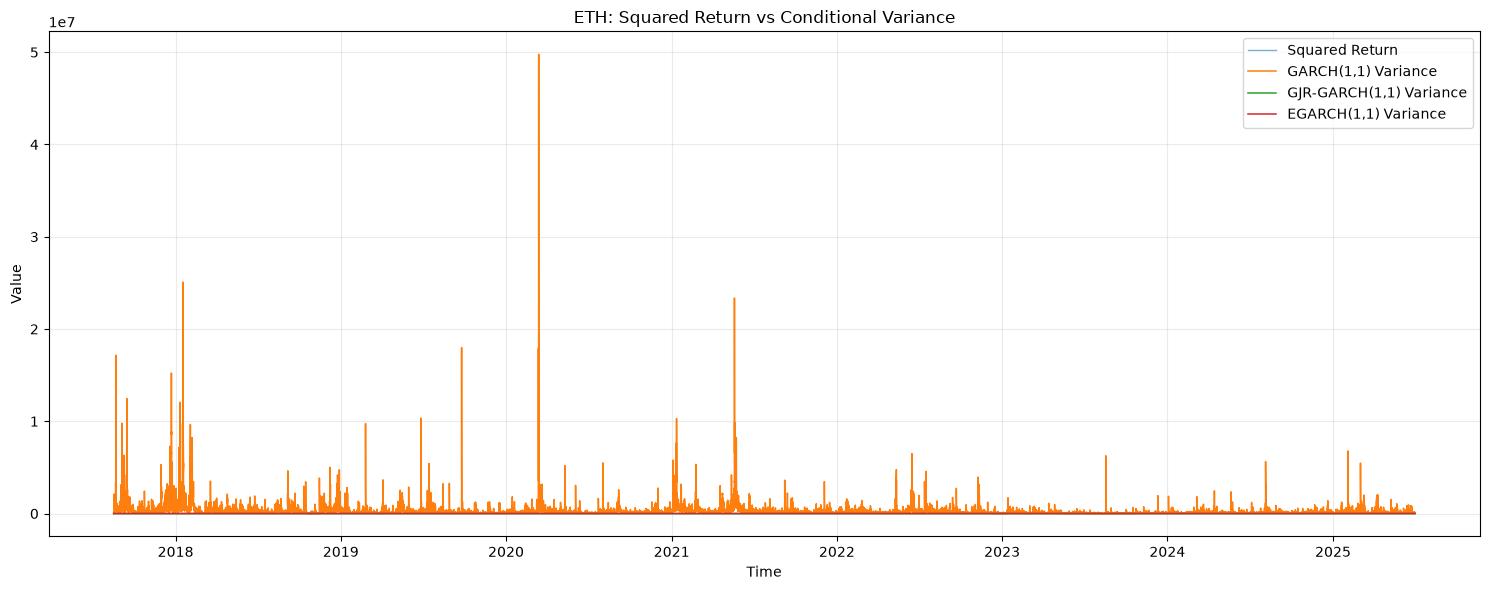

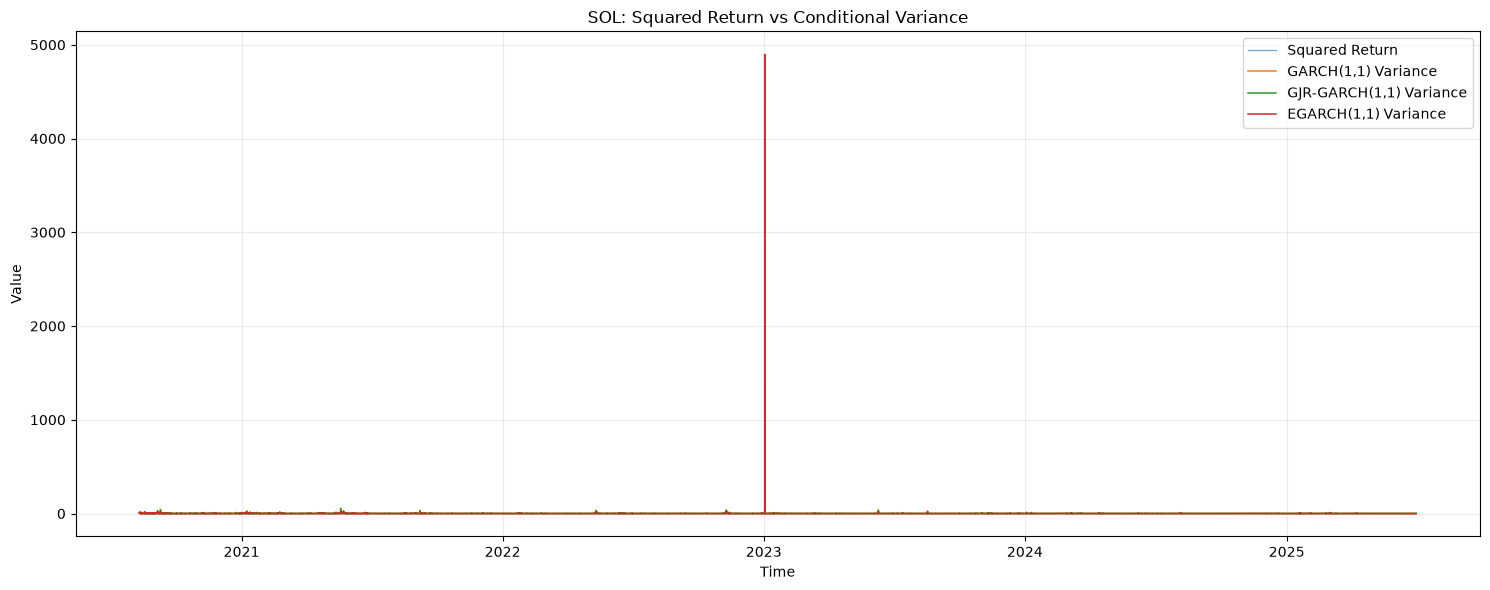

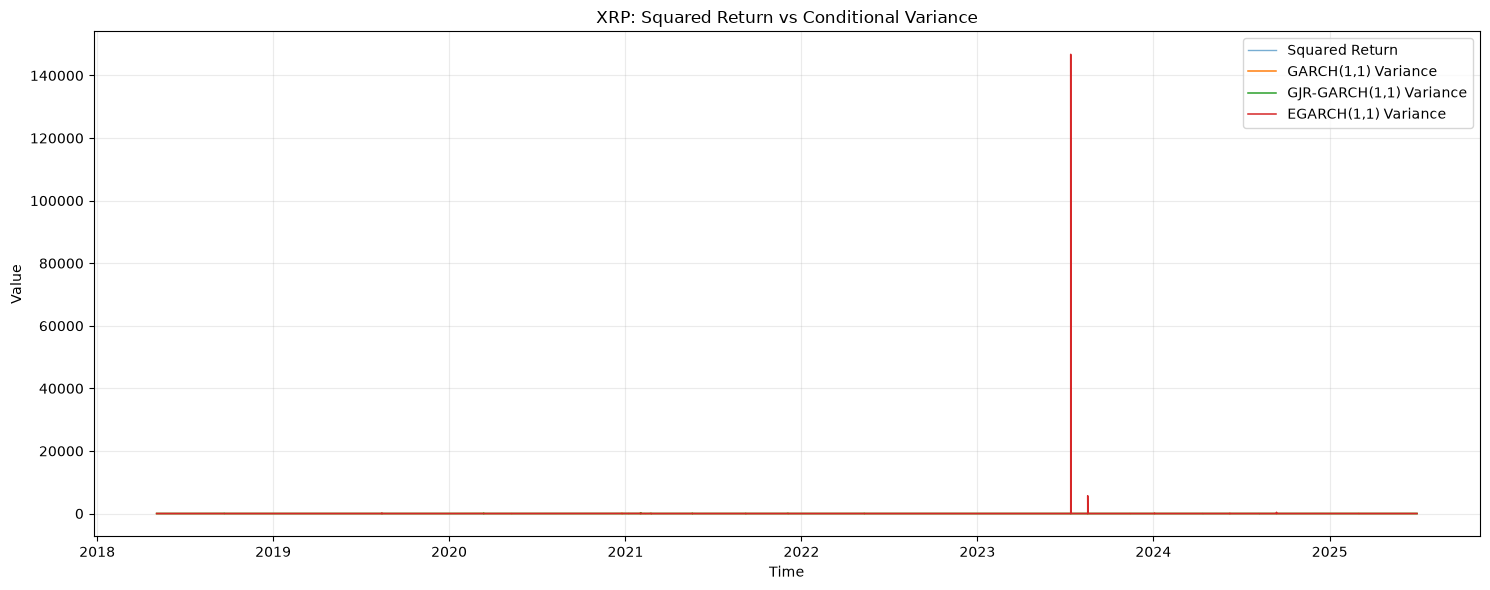

In [18]:
returns_file = "data/processed/squared_returns.xlsx"
variance_file = "data/models/arch_models_all.xlsx"

def read_time_index_excel(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
    df.index = pd.to_datetime(df.index, errors="coerce")
    df.index.name = "close_time"
    return df.reset_index()

returns_df = read_time_index_excel(returns_file, sheet_name="Sheet1")
variance_df = read_time_index_excel(variance_file, sheet_name="all_model_variances")

plot_df = returns_df.merge(variance_df, on="close_time", how="inner").sort_values("close_time")

assets = ["BTC", "ETH", "SOL", "XRP"]
models = ["GARCH(1,1)", "GJR-GARCH(1,1)", "EGARCH(1,1)"]
# models = ["GARCH(1,1)"]

for asset in assets:
    variance_columns = [f"{model}::{asset}" for model in models]
    required_columns = ["close_time", asset] + variance_columns
    asset_df = plot_df[required_columns].dropna(subset=[asset] + variance_columns, how="all").copy()

    if asset_df.empty:
        continue

    asset_df["Squared Return"] = asset_df[asset].pow(2)

    plt.figure(figsize=(15, 6))
    plt.plot(asset_df["close_time"], asset_df["Squared Return"], label="Squared Return", linewidth=1.0, alpha=0.6)

    for model, variance_column in zip(models, variance_columns):
        if variance_column in asset_df.columns:
            plt.plot(asset_df["close_time"], asset_df[variance_column], label=f"{model} Variance", linewidth=1.1)

    plt.title(f"{asset}: Squared Return vs Conditional Variance")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [19]:
# import pandas as pd
# import matplotlib.pyplot as plt

# def make_excel_safe(df):
#     df = df.copy()

#     if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
#         df.index = df.index.tz_convert(None)

#     for col in df.columns:
#         if pd.api.types.is_datetime64tz_dtype(df[col]):
#             df[col] = df[col].dt.tz_convert(None)

#     return df

# returns_file = "data/processed/squared_returns.xlsx"
# variance_file = "data/models/arch_models_all.xlsx"

# returns_df = pd.read_excel(returns_file, sheet_name="Sheet1")
# variance_df = pd.read_excel(variance_file, sheet_name="all_model_variances")

# # Normalize time columns
# for df, col_name in [(returns_df, "close_time"), (variance_df, "close_time")]:
#     if col_name in df.columns:
#         df[col_name] = pd.to_datetime(df[col_name], errors="coerce")
#     elif df.index.name is not None:
#         df = df.reset_index()
#         df[col_name] = pd.to_datetime(df[col_name], errors="coerce")

# returns_df = make_excel_safe(returns_df)
# variance_df = make_excel_safe(variance_df)

# plot_df = returns_df.merge(variance_df, on="close_time", how="inner").sort_values("close_time")

# assets = ["BTC", "ETH", "SOL", "XRP"]
# models = ["GARCH(1,1)", "GJR-GARCH(1,1)", "EGARCH(1,1)"]

# for asset in assets:
#     variance_columns = [f"{model}::{asset}" for model in models]

#     required_columns = ["close_time", asset] + variance_columns
#     asset_df = plot_df[required_columns].dropna(subset=[asset] + variance_columns, how="all").copy()

#     if asset_df.empty:
#         continue

#     asset_df["Squared Return"] = asset_df[asset].pow(2)

#     plt.figure(figsize=(15, 6))
#     plt.plot(
#         asset_df["close_time"],
#         asset_df["Squared Return"],
#         label="Squared Return",
#         linewidth=1.0,
#         alpha=0.6,
#     )

#     for model, variance_column in zip(models, variance_columns):
#         if variance_column in asset_df.columns:
#             plt.plot(
#                 asset_df["close_time"],
#                 asset_df[variance_column],
#                 label=f"{model} Variance",
#                 linewidth=1.1,
#             )

#     plt.title(f"{asset}: Squared Return vs Conditional Variance")
#     plt.xlabel("Time")
#     plt.ylabel("Value")
#     plt.legend()
#     plt.grid(alpha=0.25)
#     plt.tight_layout()
#     plt.show()

In [20]:
# import pandas as pd
# import matplotlib.pyplot as plt

# returns_file = "data/processed/squared_returns.xlsx"
# variance_file = "data/models/arch_models_all.xlsx"

# returns_df = pd.read_excel(
#     returns_file,
#     sheet_name="Sheet1"
# )

# variance_df = pd.read_excel(
#     variance_file,
#     sheet_name="all_model_variances"
# )

# # Convert date columns to datetime
# returns_df["close_time"] = pd.to_datetime(returns_df["close_time"])
# variance_df["close_time"] = pd.to_datetime(variance_df["close_time"])

# plot_df = returns_df.merge(
#     variance_df,
#     on="close_time",
#     how="inner"
# )

# assets = ["BTC", "ETH", "SOL", "XRP"]

# models = [
#     "GARCH(1,1)",
#     "GJR-GARCH(1,1)",
#     "EGARCH(1,1)"
# ]

# for asset in assets:

#     variance_columns = [
#         f"{model}::{asset}" for model in models
#     ]

#     required_columns = [
#         "close_time",
#         asset
#     ] + variance_columns

#     asset_df = plot_df[required_columns].dropna().copy()

#     # Calculate squared returns
#     asset_df["Squared Return"] = asset_df[asset] ** 2

#     plt.figure(figsize=(15, 6))

#     # Plot squared returns
#     plt.plot(
#         asset_df["close_time"],
#         asset_df["Squared Return"],
#         label="Squared Return",
#         linewidth=0.6,
#         alpha=0.45
#     )

#     # Plot conditional variance from every model
#     for model, variance_column in zip(models, variance_columns):

#         plt.plot(
#             asset_df["close_time"],
#             asset_df[variance_column],
#             label=f"{model} Variance",
#             linewidth=1.1
#         )

#     plt.title(
#         f"{asset}: Squared Return and Conditional Variance Estimates"
#     )
#     plt.xlabel("Time")
#     plt.ylabel("Variance")
#     plt.legend()
#     plt.grid(alpha=0.25)
#     plt.tight_layout()
#     plt.show()

In [21]:
# import sys
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import unittest
# from tempfile import TemporaryDirectory

# sys.path.insert(0, str(Path.cwd()))

# try:
#     from arch_models import (
#         compare_conditional_variances,
#         load_variance_data,
#         load_returns_data,
#         load_and_compare_variances,
#     )
# except Exception:
#     def load_variance_data(excel_path, sheet_name="all_model_variances"):
#         excel_path = Path(excel_path)
#         if not excel_path.exists():
#             raise FileNotFoundError(f"Excel file not found: {excel_path}")
#         var_df = pd.read_excel(excel_path, sheet_name=sheet_name, index_col=0)
#         if not isinstance(var_df.index, pd.DatetimeIndex):
#             var_df.index = pd.to_datetime(var_df.index)
#         return var_df

#     def load_returns_data(parquet_path):
#         parquet_path = Path(parquet_path)
#         if not parquet_path.exists():
#             raise FileNotFoundError(f"Parquet file not found: {parquet_path}")
#         df = pd.read_parquet(parquet_path)
#         if "date" in df.columns:
#             df["date"] = pd.to_datetime(df["date"], utc=True)
#             df = df.set_index("date")
#         elif not isinstance(df.index, pd.DatetimeIndex):
#             df.index = pd.to_datetime(df.index, utc=True)
#         return df.sort_index()

#     def _parse_variance_column_name(column_name):
#         if isinstance(column_name, str) and "::" in column_name:
#             model_name, asset_name = column_name.split("::", 1)
#             return model_name.strip(), asset_name.strip()
#         return str(column_name), None

#     def compare_conditional_variances(variance_data, returns_data, asset_names=None):
#         if isinstance(variance_data, (str, Path)):
#             variance_df = load_variance_data(variance_data)
#         else:
#             variance_df = variance_data.copy()

#         if isinstance(returns_data, (str, Path)):
#             returns_df = load_returns_data(returns_data)
#         else:
#             returns_df = returns_data.copy()

#         if asset_names is None:
#             asset_names = [
#                 c
#                 for c in returns_df.columns
#                 if pd.api.types.is_numeric_dtype(returns_df[c]) and c not in {"date"}
#             ]

#         rows = []
#         for asset in asset_names:
#             if asset not in returns_df.columns:
#                 continue

#             actual_series = returns_df[asset].dropna()
#             if actual_series.empty:
#                 continue

#             squared_actual = actual_series.pow(2)

#             for column in variance_df.columns:
#                 model_name, parsed_asset = _parse_variance_column_name(column)

#                 if parsed_asset is not None and parsed_asset != asset:
#                     continue

#                 if parsed_asset is None and column != asset:
#                     continue

#                 predicted_series = variance_df[column].dropna()
#                 aligned = pd.concat([squared_actual, predicted_series], axis=1, join="inner").dropna()
#                 if aligned.empty:
#                     continue

#                 actual_vals = aligned.iloc[:, 0].astype(float)
#                 predicted_vals = aligned.iloc[:, 1].astype(float)

#                 rmse = np.sqrt(np.mean((predicted_vals - actual_vals) ** 2))
#                 mae = np.mean(np.abs(predicted_vals - actual_vals))

#                 rows.append(
#                     {
#                         "asset": asset,
#                         "model": model_name,
#                         "variance_column": column,
#                         "rmse": rmse,
#                         "mae": mae,
#                         "n_obs": len(aligned),
#                     }
#                 )

#         return pd.DataFrame(rows)

#     def load_and_compare_variances(
#         excel_path,
#         parquet_path,
#         sheet_name="all_model_variances",
#         asset_names=None,
#     ):
#         variance_df = load_variance_data(excel_path, sheet_name=sheet_name)
#         returns_df = load_returns_data(parquet_path)
#         return compare_conditional_variances(variance_df, returns_df, asset_names=asset_names)


# # %%
# class TestArchModelVarianceMetrics(unittest.TestCase):
#     def test_load_variance_data_reads_excel(self):
#         with TemporaryDirectory() as tmpdir:
#             tmp_path = Path(tmpdir) / "variance.xlsx"
#             index = pd.to_datetime(["2024-01-01", "2024-01-02", "2024-01-03"])
#             variance_df = pd.DataFrame(
#                 {
#                     "GARCH::BTC": [1.0, 2.0, 3.0],
#                     "EGARCH::BTC": [1.5, 2.5, 3.5],
#                 },
#                 index=index,
#             )

#             with pd.ExcelWriter(tmp_path, engine="openpyxl") as writer:
#                 variance_df.to_excel(writer, sheet_name="all_model_variances")

#             loaded = load_variance_data(tmp_path)

#             self.assertEqual(list(loaded.columns), ["GARCH::BTC", "EGARCH::BTC"])
#             self.assertTrue(isinstance(loaded.index, pd.DatetimeIndex))
#             self.assertEqual(loaded.index[0], index[0])

#     def test_compare_conditional_variances_calculates_rmse_and_mae(self):
#         index = pd.to_datetime(["2024-01-01", "2024-01-02", "2024-01-03"])
#         variance_df = pd.DataFrame(
#             {
#                 "GARCH::BTC": [1.0, 2.0, 3.0],
#                 "EGARCH::BTC": [0.5, 2.5, 3.5],
#             },
#             index=index,
#         )
#         returns_df = pd.DataFrame({"BTC": [1.0, -1.0, 2.0]}, index=index)

#         result = compare_conditional_variances(
#             variance_df,
#             returns_df,
#             asset_names=["BTC"],
#         )

#         self.assertFalse(result.empty)
#         self.assertIn("rmse", result.columns)
#         self.assertIn("mae", result.columns)
#         self.assertEqual(set(result["asset"].tolist()), {"BTC"})
#         self.assertEqual(set(result["model"].tolist()), {"GARCH", "EGARCH"})
#         self.assertTrue((result["rmse"] >= 0).all())
#         self.assertTrue((result["mae"] >= 0).all())

#     def test_load_and_compare_variances_reads_saved_files(self):
#         with TemporaryDirectory() as tmpdir:
#             tmpdir = Path(tmpdir)
#             excel_path = tmpdir / "saved_variances.xlsx"
#             parquet_path = tmpdir / "returns.parquet"

#             index = pd.to_datetime(["2024-01-01", "2024-01-02", "2024-01-03"])
#             variance_df = pd.DataFrame(
#                 {
#                     "GARCH::BTC": [1.0, 2.0, 3.0],
#                     "EGARCH::BTC": [1.2, 2.2, 3.2],
#                 },
#                 index=index,
#             )
#             returns_df = pd.DataFrame({"BTC": [1.0, 0.5, -1.5]}, index=index)

#             with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#                 variance_df.to_excel(writer, sheet_name="all_model_variances")

#             returns_df.to_parquet(parquet_path)

#             result = load_and_compare_variances(
#                 excel_path,
#                 parquet_path,
#                 asset_names=["BTC"],
#             )

#             self.assertFalse(result.empty)
#             self.assertIn("rmse", result.columns)
#             self.assertIn("mae", result.columns)
#             self.assertTrue((result["rmse"] >= 0).all())
#             self.assertTrue((result["mae"] >= 0).all())


# # %%
# if __name__ == "__main__":
#     unittest.main(argv=["first-arg-is-ignored"], exit=False)

In [22]:
# import os
# import pandas as pd

# excel_path = "data/processed/arch_models_all.xlsx"
# parquet_path = "data/processed/train_returns.parquet"

# variance_df = load_variance_data(excel_path, sheet_name="all_model_variances")
# returns_df = load_returns_data(parquet_path)

# asset_names = [
#     c
#     for c in returns_df.columns
#     if pd.api.types.is_numeric_dtype(returns_df[c]) and c not in {"date"}
# ]

# metrics_df = compare_conditional_variances(
#     variance_df,
#     returns_df,
#     asset_names=asset_names,
# )

# os.makedirs("data/processed", exist_ok=True)
# out_file = "data/processed/variance_metrics_all_assets.xlsx"
# metrics_df.to_excel(out_file, index=False)

# print(f"Saved metrics to: {out_file}")
# print(metrics_df.head())

In [23]:
# from arch import arch_model

# # use pct_change returns, drop NaNs
# returns = train_returns["BTC"].dropna()

# # GARCH(1,1)
# garch = arch_model(returns, vol="Garch", p=1, q=1, dist="t").fit(disp="off")
# print("=== GARCH(1,1) ===")
# print(garch.summary())
# print("\n")

# pred = garch.forecast(horizon=20, reindex=False)
# print("=== GARCH(1,1) Forecast ===")
# print(pred.variance[-1:])

In [24]:
# # GJR-GARCH(1,1)
# gjr = arch_model(returns, vol="Garch", p=1, o=1, q=1, dist="t").fit(disp="off")
# print("\n=== GJR-GARCH(1,1) ===")
# print(gjr.summary())

In [25]:
# # EGARCH(1,1)
# egarch = arch_model(returns, vol="EGARCH", p=1, o=1, q=1, dist="t").fit(disp="off")
# print("\n=== EGARCH(1,1) ===")
# print(egarch.summary())

In [26]:
# # EWMA
# lambda_ = 0.94
# ewma_var = returns.pow(2).ewm(alpha=1 - lambda_, adjust=False).mean()
# ewma_vol = np.sqrt(ewma_var)

# print("\n=== EWMA ===")
# print("Last 5 EWMA variances:")
# print(ewma_var.tail())
# print("\nLast 5 EWMA volatilities:")
# print(ewma_vol.tail())

In [27]:
# from arch import arch_model
# import os
# import numpy as np
# import pandas as pd

# # Use the train set created earlier
# train_df = train_returns.copy() if "train_returns" in globals() else train.copy()

# # Select numeric asset columns
# asset_cols = [
#     c for c in train_df.columns
#     if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
# ]

# if len(asset_cols) == 0:
#     raise ValueError("No numeric asset columns found.")

# def make_excel_safe(df):
#     df = df.copy()

#     if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
#         df.index = df.index.tz_convert(None)

#     for col in df.columns:
#         if pd.api.types.is_datetime64tz_dtype(df[col]):
#             df[col] = df[col].dt.tz_convert(None)

#     return df

# model_specs = [
#     ("GJR-GARCH", {"vol": "Garch", "p": 1, "o": 1, "q": 1}),
#     ("EGARCH", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
# ]

# for model_name, spec in model_specs:
#     rows = []
#     var_frames = []

#     for asset in asset_cols:
#         s = train_df[asset].dropna()

#         if len(s) < 50:
#             continue

#         model = arch_model(
#             s,
#             vol=spec["vol"],
#             p=spec["p"],
#             o=spec["o"],
#             q=spec["q"],
#             dist="t"
#         ).fit(disp="off", show_warning=False)

#         cond_var = pd.Series(model.conditional_volatility**2, index=s.index, name=asset)
#         var_frames.append(cond_var.to_frame())

#         row = {
#             "asset": asset,
#             "model": model_name,
#             "aic": model.aic,
#             "bic": model.bic,
#             "n_obs": len(s),
#         }

#         for param_name, value in model.params.items():
#             row[f"param_{param_name}"] = value

#         rows.append(row)

#     model_df = pd.DataFrame(rows)
#     var_df = pd.concat(var_frames, axis=1)

#     model_df = make_excel_safe(model_df)
#     var_df = make_excel_safe(var_df)

#     os.makedirs("data/processed", exist_ok=True)
#     out_file = f"data/processed/{model_name.lower().replace('-', '_')}_models.xlsx"

#     with pd.ExcelWriter(out_file) as writer:
#         model_df.to_excel(writer, sheet_name=f"{model_name.lower().replace('-', '_')}_results", index=False)
#         var_df.to_excel(writer, sheet_name=f"{model_name.lower().replace('-', '_')}_variance", index=False)

#     print(f"Saved {model_name} results to: {out_file}")
#     print(model_df.head())
#     print("\n")

In [28]:
# import matplotlib.pyplot as plt
# import scipy.stats as stats
# from statsmodels.graphics.gofplots import qqplot
# from statsmodels.stats.diagnostic import acorr_ljungbox

# models = {
#     "GARCH(1,1)": garch,
#     "GJR-GARCH(1,1)": gjr,
#     "EGARCH(1,1)": egarch,
# }

# for name, model in models.items():
#     std_resid = model.resid / model.conditional_volatility
#     std_resid = std_resid.dropna()

#     k2_stat, k2_p = stats.normaltest(std_resid)
#     shapiro_stat, shapiro_p = stats.shapiro(std_resid)
#     lb_test = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)    

#     print(f"=== {name} ===")
#     print(f"normaltest: stat={k2_stat:.4f}, p={k2_p:.4f}")
#     print(f"Shapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")
#     print()
#     print(lb_test)

#     plt.figure(figsize=(6, 6))
#     qqplot(std_resid, line="s", ax=plt.gca())
#     plt.title(f"{name} standardized residuals QQ plot")
#     plt.xlabel("Theoretical quantiles")
#     plt.ylabel("Sample quantiles")
#     plt.tight_layout()
#     plt.show()



In [29]:
# from arch import arch_model
# import os
# import numpy as np
# import pandas as pd

# # Use the split data created earlier
# train_df = train_returns.copy() if "train_returns" in globals() else train.copy()
# test_df = test_returns.copy() if "test_returns" in globals() else test.copy()

# # Select numeric columns (assets)
# asset_cols = [
#     c for c in train_df.columns
#     if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
# ]
# asset_cols = [c for c in asset_cols if c in test_df.columns]

# if len(asset_cols) == 0:
#     raise ValueError("No numeric asset columns found.")

# model_specs = [
#     ("GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 0, "q": 1}),
#     ("GJR-GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 1, "q": 1}),
#     ("EGARCH(1,1)", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
# ]

# def rolling_forecast(train_series, test_series, spec):
#     history = train_series.dropna().copy()
#     preds_var = []
#     filtered_test = test_series.dropna()

#     for idx, y in filtered_test.items():
#         res = arch_model(
#             history,
#             vol=spec["vol"],
#             p=spec["p"],
#             o=spec["o"],
#             q=spec["q"],
#             dist="t"
#         ).fit(disp="off", show_warning=False)

#         fc = res.forecast(horizon=1)
#         pred_var = float(fc.variance.iloc[-1, 0])
#         preds_var.append(pred_var)

#         history = pd.concat([history, pd.Series([y], index=[idx])])

#     return pd.Series(preds_var, index=filtered_test.index)

# rows = []

# for asset in asset_cols:
#     train_series = train_df[asset].dropna()
#     test_series = test_df[asset].dropna()

#     if len(train_series) < 50 or len(test_series) < 5:
#         continue

#     for model_name, spec in model_specs:
#         res = arch_model(
#             train_series,
#             vol=spec["vol"],
#             p=spec["p"],
#             o=spec["o"],
#             q=spec["q"],
#             dist="t"
#         ).fit(disp="off", show_warning=False)

#         pred_var = rolling_forecast(train_series, test_series, spec)
#         actual_var = test_series.pow(2)
#         actual_vol = test_series.abs()
#         pred_vol = np.sqrt(pred_var)

#         rmse_var = np.sqrt(np.mean((pred_var - actual_var) ** 2))
#         mae_var = np.mean(np.abs(pred_var - actual_var))
#         rmse_vol = np.sqrt(np.mean((pred_vol - actual_vol) ** 2))
#         mae_vol = np.mean(np.abs(pred_vol - actual_vol))

#         row = {
#             "asset": asset,
#             "model": model_name,
#             "rmse_var": rmse_var,
#             "mae_var": mae_var,
#             "rmse_vol": rmse_vol,
#             "mae_vol": mae_vol,
#             "aic": res.aic,
#             "bic": res.bic,
#             "n_test": len(test_series),
#         }

#         # Add model parameters as columns
#         for param_name, value in res.params.items():
#             row[f"param_{param_name}"] = value

#         rows.append(row)

# model_df = pd.DataFrame(rows)

# os.makedirs("data/processed", exist_ok=True)
# out_file = "data/processed/arch_model_results.xlsx"

# with pd.ExcelWriter(out_file) as writer:
#     model_df.to_excel(writer, sheet_name="arch_models", index=False)

# print(f"Saved {len(model_df)} model results to {out_file}")
# model_df.head()